# UK NHS Dataset Modeling

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

### Reading the Dataset

In [2]:
data = pd.read_csv("dataset/Hospital.csv")
data.head(10)

,OrganisationID,OrganisationCode,OrganisationType,SubType,Sector,OrganisationStatus,IsPimsManaged,OrganisationName,Address1,Address2,...,County,Postcode,Latitude,Longitude,ParentODSCode,ParentName,Phone,Email,Website,"Fax,,,"
0,17970,NDA07,Hospital,Hospital,Independent Sector,Visible,True,Walton Community Hospital - Virgin Care Servic...,NaN,Rodney Road,...,Surrey,KT12 3LD,51.379997,-0.406042,NDA,Virgin Care Services Ltd,01932 414205,NaN,NaN,"01932 253674,,,"
1,17981,NDA18,Hospital,Hospital,Independent Sector,Visible,True,Woking Community Hospital (Virgin Care),NaN,Heathside Road,...,Surrey,GU22 7HS,51.315132,-0.556289,NDA,Virgin Care Services Ltd,01483 715911,NaN,NaN,",,,"
2,18102,NLT02,Hospital,Hospital,NHS Sector,Visible,True,North Somerset Community Hospital,North Somerset Community Hospital,Old Street,...,Avon,BS21 6BS,51.437195,-2.847193,NLT,North Somerset Community Partnership Community...,01275 872212,NaN,http://www.nscphealth.co.uk,",,,"
3,18138,NMP01,Hospital,Hospital,Independent Sector,Visible,False,Bridgewater Hospital,120 Princess Road,NaN,...,Greater Manchester,M15 5AT,53.459743,-2.245469,NMP,Bridgewater Hospital (Manchester) Ltd,0161 2270000,NaN,www.bridgewaterhospital.com,",,,"
4,18142,NMV01,Hospital,Hospital,Independent Sector,Visible,True,Kneesworth House,Old North Road,Bassingbourn,...,NaN,SG8 5JP,52.078121,-0.030604,NMV,Partnerships In Care Ltd,01763 255 700,reception_kneesworthhouse@partnershipsincare.c...,www.partnershipsincare.co.uk,",,,"
5,18143,NMV02,Hospital,Hospital,Independent Sector,Visible,True,Stockton Hall Hospital,Stockton Hall,The Village,...,North Yorkshire,YO32 9UN,53.995403,-1.002553,NMV,Partnerships In Care Ltd,01904 400 500,info@priorygroup.com,https://www.priorygroup.com/stockton-hall,",,,"
6,18271,NQ106,Hospital,Hospital,Independent Sector,Visible,True,"Fryatt Hospital, Harwich",419 Main Road,NaN,...,Essex,CO12 4EX,51.934696,1.261444,NQ1,Anglian Community Enterprise Community Interes...,01255 201200,NaN,NaN,",,"
7,18272,NQ108,Hospital,Hospital,Independent Sector,Visible,True,Clacton Hospital,NaN,Tower Road,...,Essex,CO15 1LH,51.786079,1.148188,NQ1,Anglian Community Enterprise Community Interes...,01255 201717,NaN,https://www.esneft.nhs.uk/your-visit/our-wards...,"01206 286710,,,"
8,18289,NQ901,Hospital,Hospital,Independent Sector,Visible,False,Lakeside Hospital,The Lane,Wyboston,...,Bedfordshire,MK44 3AS,52.198326,-0.310281,NQ9,Brookdale Healthcare Ltd (T/A Brookdale Care),NaN,NaN,NaN,",,,"
9,18305,NQM01,Hospital,Hospital,Independent Sector,Visible,True,Orthopaedics and Spine Specialist Hospital,1 Stirling Way,Bretton,...,Cambridgeshire,PE3 8YA,52.604942,-0.283022,NQM,Orthopaedics and Spine Specialist Hospital,01733 333156,info@orthospine.co.uk,NaN,"01733 373050,,,"


### Understanding the dataset

In [3]:
data.columns

Index(['OrganisationID', 'OrganisationCode', 'OrganisationType', 'SubType',
       'Sector', 'OrganisationStatus', 'IsPimsManaged', 'OrganisationName',
       'Address1', 'Address2', 'Address3', 'City', 'County', 'Postcode',
       'Latitude', 'Longitude', 'ParentODSCode', 'ParentName', 'Phone',
       'Email', 'Website', 'Fax,,,'],
      dtype='object')

### Check the datatypes

In [4]:
data.dtypes

OrganisationID          int64
OrganisationCode       object
OrganisationType       object
SubType                object
Sector                 object
OrganisationStatus     object
IsPimsManaged            bool
OrganisationName       object
Address1               object
Address2               object
Address3               object
City                   object
County                 object
Postcode               object
Latitude              float64
Longitude             float64
ParentODSCode          object
ParentName             object
Phone                  object
Email                  object
Website                object
Fax,,,                 object
dtype: object

### Shape of Dataset

In [5]:
print('UK NHS dataset shape:',data.shape)

UK NHS dataset shape: (1211, 22)


### Dataset info

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1211 entries, 0 to 1210
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OrganisationID      1211 non-null   int64  
 1   OrganisationCode    1211 non-null   object 
 2   OrganisationType    1211 non-null   object 
 3   SubType             1211 non-null   object 
 4   Sector              1211 non-null   object 
 5   OrganisationStatus  1211 non-null   object 
 6   IsPimsManaged       1211 non-null   bool   
 7   OrganisationName    1211 non-null   object 
 8   Address1            883 non-null    object 
 9   Address2            727 non-null    object 
 10  Address3            147 non-null    object 
 11  City                1196 non-null   object 
 12  County              973 non-null    object 
 13  Postcode            1210 non-null   object 
 14  Latitude            1209 non-null   float64
 15  Longitude           1209 non-null   float64
 16  ParentODSCo

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
OrganisationID,1211.0,1.375611e+06,3.024986e+06,17970.000000,40649.000000,43110.000000,76107.000000,1.095615e+07
Latitude,1209.0,5.231751e+01,1.213026e+00,49.913063,51.410404,52.038059,53.378357,5.577329e+01
Longitude,1209.0,-1.293855e+00,1.294781e+00,-6.309277,-2.154729,-1.369305,-0.217204,1.730521e+00


### Numeric Features Visaulization

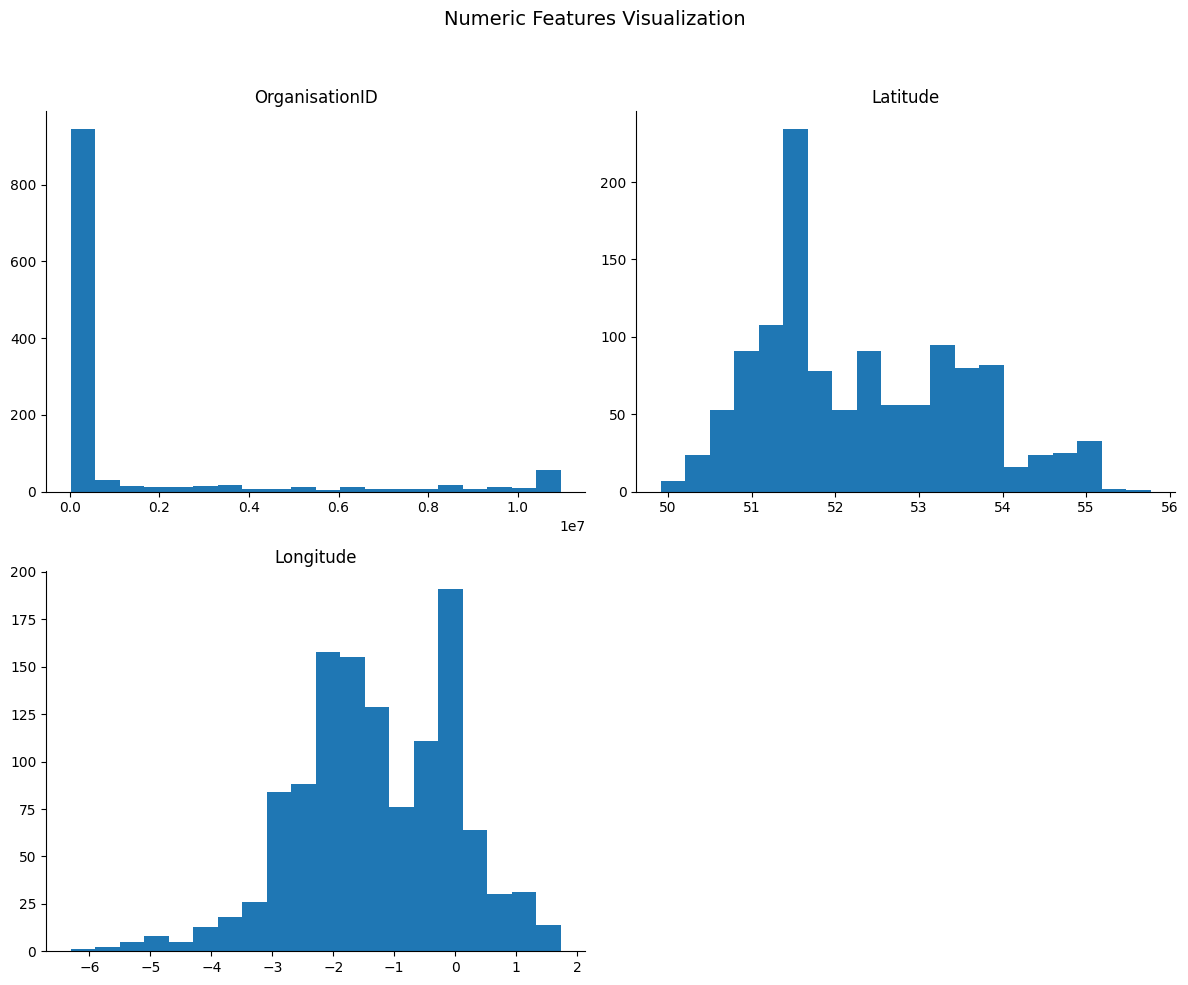

In [8]:
data.hist(figsize=(12,10), bins=20, grid=False)
sns.despine()
plt.suptitle("Numeric Features Visualization", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

### Heat Map for Correlation

<Axes: >

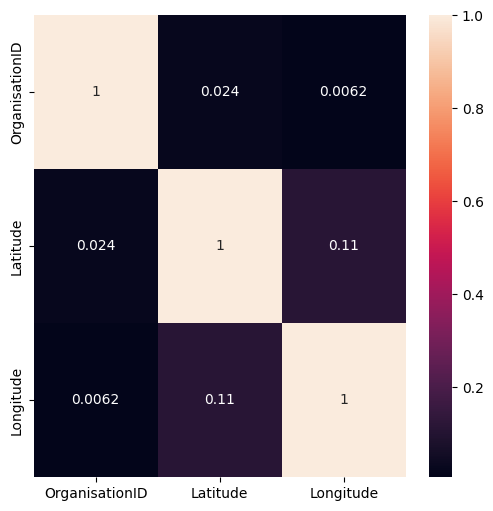

In [9]:
matrix = data.drop(columns=["IsPimsManaged"]).corr(numeric_only=True)
f, ax = plt.subplots(figsize=(6,6))
sns.heatmap(matrix.abs(),annot=True)

CPU times: user 1.15 s, sys: 1.94 s, total: 3.09 s
Wall time: 564 ms


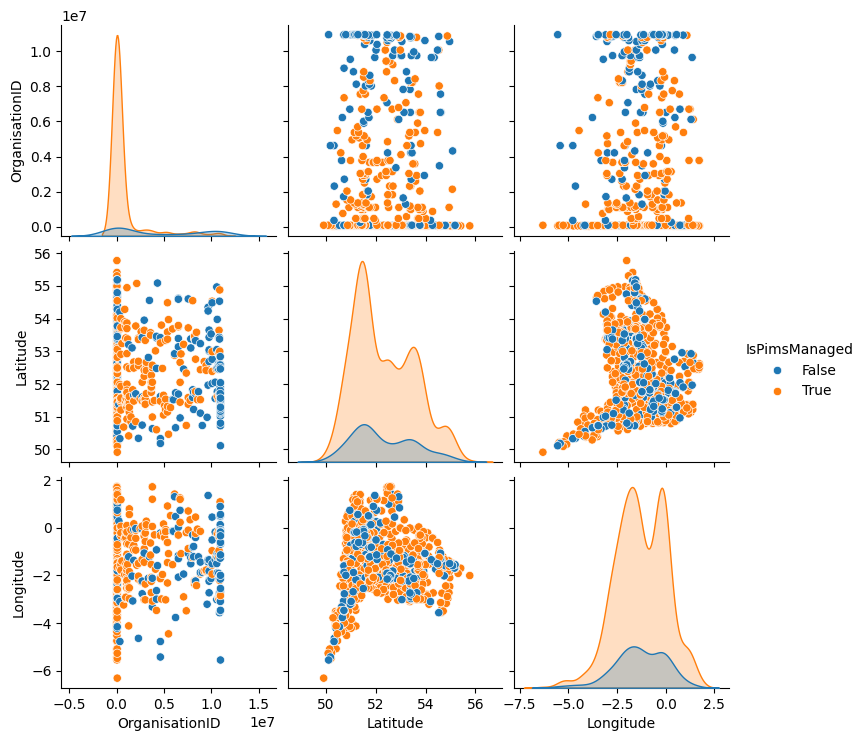

In [10]:
%time sns.pairplot(data, hue="IsPimsManaged", height=2.5)

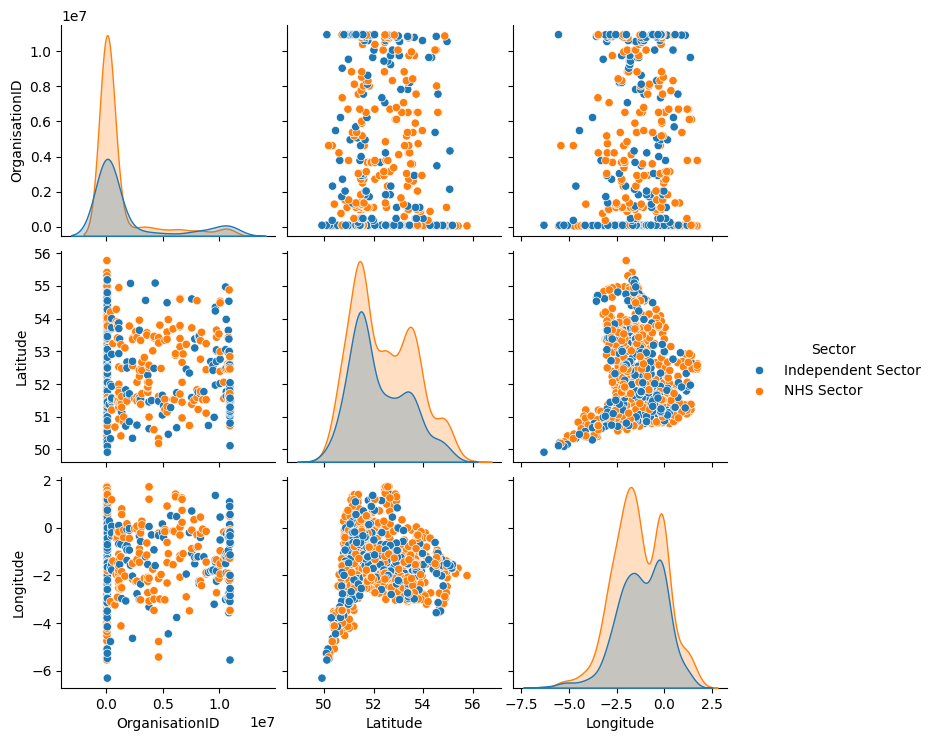

In [11]:
sns.pairplot(data.drop(columns=["IsPimsManaged"]), hue="Sector", height=2.5)

## Data Processing

### Check Null value

In [12]:
data.isnull().sum()

OrganisationID           0
OrganisationCode         0
OrganisationType         0
SubType                  0
Sector                   0
OrganisationStatus       0
IsPimsManaged            0
OrganisationName         0
Address1               328
Address2               484
Address3              1064
City                    15
County                 238
Postcode                 1
Latitude                 2
Longitude                2
ParentODSCode            0
ParentName               0
Phone                  250
Email                  789
Website                358
Fax,,,                   2
dtype: int64

### Replacing null values of categorical variable using mode

In [13]:
data.fillna({"Address1": data["Address1"].mode()[0]},inplace=True)
data.fillna({"Address2": data["Address2"].mode()[0]},inplace=True)
data.fillna({"Address3": data["Address3"].mode()[0]},inplace=True)
data.fillna({"City": data["City"].mode()[0]},inplace=True)
data.fillna({"County": data["County"].mode()[0]},inplace=True)
data.fillna({"Postcode": data["Postcode"].mode()[0]},inplace=True)
data.fillna({"County": data["County"].mode()[0]},inplace=True)
data.fillna({"Phone": data["Phone"].mode()[0]},inplace=True)
data.fillna({"Email": data["Email"].mode()[0]},inplace=True)
data.fillna({"Website": data["Website"].mode()[0]},inplace=True)
data.fillna({"Fax,,,": data["Fax,,,"].mode()[0]},inplace=True)

### Replacing null values of numerical variables using Mean or Median

In [14]:
data.fillna({"Latitude": data["Latitude"].median()}, inplace=True)
data.fillna({"Longitude": data["Longitude"].median()}, inplace=True)

### Check Duplicated

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.describe(include='object').T

,count,unique,top,freq
OrganisationCode,1211,1211,NDA07,1
OrganisationType,1211,1,Hospital,1211
SubType,1211,3,Hospital,961
Sector,1211,2,NHS Sector,743
OrganisationStatus,1211,1,Visible,1211
OrganisationName,1211,1189,St Mary's Hospital,6
Address1,1211,825,London Road,335
Address2,1211,662,Edgbaston,490
Address3,1211,130,Headington,1071
City,1211,532,London,110


### Build the Model

In [17]:
data = data.drop(columns=["OrganisationID","OrganisationCode","City","ParentODSCode","ParentName","OrganisationType","OrganisationStatus","OrganisationName","Address1","Address2","Address3","Postcode","Phone","Email","Website","Fax,,,"])
data["IsPimsManaged"] = data["IsPimsManaged"].astype(int)
data.head(5)

,SubType,Sector,IsPimsManaged,County,Latitude,Longitude
0,Hospital,Independent Sector,1,Surrey,51.379997,-0.406042
1,Hospital,Independent Sector,1,Surrey,51.315132,-0.556289
2,Hospital,NHS Sector,1,Avon,51.437195,-2.847193
3,Hospital,Independent Sector,0,Greater Manchester,53.459743,-2.245469
4,Hospital,Independent Sector,1,Kent,52.078121,-0.030604


In [18]:
X = data.drop(columns="Sector")
X = pd.get_dummies(X)
cols_to_int = X.columns.difference(['Latitude', 'Longitude'])
X[cols_to_int] = X[cols_to_int].astype(int)
X.head(5)

,IsPimsManaged,Latitude,Longitude,SubType_Hospital,SubType_Mental Health Hospital,SubType_UNKNOWN,County_Avon,County_Bedfordshire,County_Berkshire,County_Buckinghamshire,...,County_Sussex,County_Tyne and Wear,County_Warwickshire,County_West Midlands,County_West Sussex,County_West Yorkshire,County_Wiltshire,County_Worcestershire,County_Yorkshire,County_Yorkshire(East Riding)
0,1,51.379997,-0.406042,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,51.315132,-0.556289,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,51.437195,-2.847193,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,53.459743,-2.245469,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,52.078121,-0.030604,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
y= data["Sector"].map({'NHS Sector': 1, 'Independent Sector': 0})
y.head(5)

0    0
1    0
2    1
3    0
4    0
Name: Sector, dtype: int64

### Analysis of Sector Feature

<Axes: xlabel='Sector', ylabel='count'>

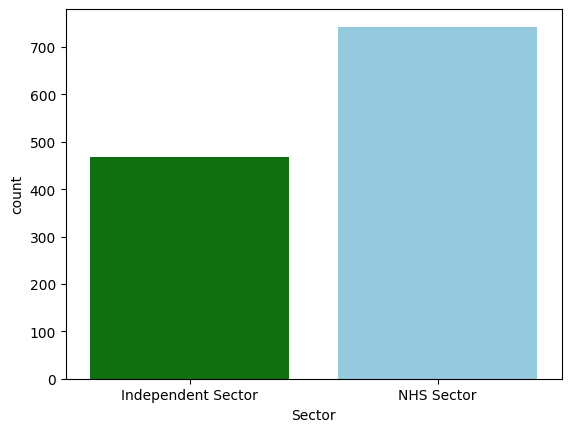

In [20]:
sns.countplot(x="Sector", hue="Sector", data=data, palette=['green',  'skyblue'])

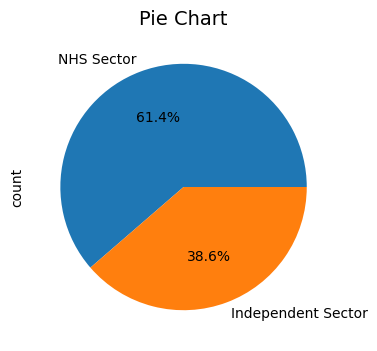

In [21]:
# pie chart for the Sector
plt.figure(figsize=(6,4))
data["Sector"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title('Pie Chart', fontsize=14)
plt.show()

### Split the Dataset into training and testing sets

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# Scale — fit on train, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Building

#### Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
# Fit model on scaled data
log_reg = LogisticRegression(max_iter=1000)
X_train_scaled.shape

(847, 60)

In [25]:
y_train.shape

(847,)

In [26]:
log_reg.fit(X_train_scaled, y_train)

/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

LogisticRegression(max_iter=1000)

In [27]:
pred_logistic=log_reg.predict(X_test.values)

/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [28]:
print(classification_report(y_test, pred_logistic))
print(confusion_matrix(y_test, pred_logistic))

logistic_score =accuracy_score(pred_logistic,y_test)*100 
print('Logistic Regression Score: ',logistic_score)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       137
           1       0.62      1.00      0.77       227

    accuracy                           0.62       364
   macro avg       0.31      0.50      0.38       364
weighted avg       0.39      0.62      0.48       364

[[  0 137]
 [  0 227]]
Logistic Regression Score:  62.362637362637365


/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

### Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
dtr = DecisionTreeClassifier()

In [31]:
dtr.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [32]:
pred_dtr=dtr.predict(X_test.values)

In [33]:
print(classification_report(y_test, pred_dtr))
print(confusion_matrix(y_test, pred_dtr))

dtr_score = accuracy_score(y_test, pred_dtr)*100
print('Decision Tree Score', dtr_score)

              precision    recall  f1-score   support

           0       0.52      0.34      0.41       137
           1       0.67      0.81      0.73       227

    accuracy                           0.63       364
   macro avg       0.59      0.57      0.57       364
weighted avg       0.61      0.63      0.61       364

[[ 46  91]
 [ 43 184]]
Decision Tree Score 63.18681318681318


### Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf = RandomForestClassifier()

In [36]:
rf.fit(X_train_scaled,y_train)

RandomForestClassifier()

In [37]:
pred_rf = rf.predict(X_test.values)

In [38]:
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

rf_score = accuracy_score(y_test, pred_rf)*100
print('Random Forest Score:', rf_score )

              precision    recall  f1-score   support

           0       0.33      0.01      0.01       137
           1       0.62      0.99      0.77       227

    accuracy                           0.62       364
   macro avg       0.48      0.50      0.39       364
weighted avg       0.51      0.62      0.48       364

[[  1 136]
 [  2 225]]
Random Forest Score: 62.08791208791209


### Support Vector Machine

In [39]:
from sklearn.svm import SVC

In [40]:
svm = SVC()

In [41]:
svm.fit(X_train_scaled, y_train)

SVC()

In [42]:
pred_svm = svm.predict(X_test.values)

In [43]:
print(classification_report(y_test,pred_svm))
print(confusion_matrix(y_test,pred_svm))

svm_score = accuracy_score(y_test,pred_svm)*100
print('Support Vector Machine Score:',svm_score)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       137
           1       0.62      1.00      0.77       227

    accuracy                           0.62       364
   macro avg       0.31      0.50      0.38       364
weighted avg       0.39      0.62      0.48       364

[[  0 137]
 [  0 227]]
Support Vector Machine Score: 62.362637362637365


/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

### K-Nearest Neighbor

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn = KNeighborsClassifier()

In [46]:
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [47]:
pred_knn = knn.predict(X_test.values)

In [48]:
print(classification_report(y_test,pred_knn))
print(confusion_matrix(y_test,pred_knn))

knn_score = accuracy_score(y_test,pred_knn)*100
print('K-Nearest Neighbor Score:', knn_score)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       137
           1       0.62      1.00      0.77       227

    accuracy                           0.62       364
   macro avg       0.31      0.50      0.38       364
weighted avg       0.39      0.62      0.48       364

[[  0 137]
 [  0 227]]
K-Nearest Neighbor Score: 62.362637362637365


/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/suraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

## Model Comparision

In [49]:
compare = pd.DataFrame({'Model': ['Logistic Regression', 'Random Forest', 'Decission Tree', 'Support Vector Machine', 'K Neighbors'],
                       'Accuracy': [logistic_score, rf_score, dtr_score, svm_score, knn_score]})

In [50]:
compare.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Decission Tree,63.186813
0,Logistic Regression,62.362637
3,Support Vector Machine,62.362637
4,K Neighbors,62.362637
1,Random Forest,62.087912
